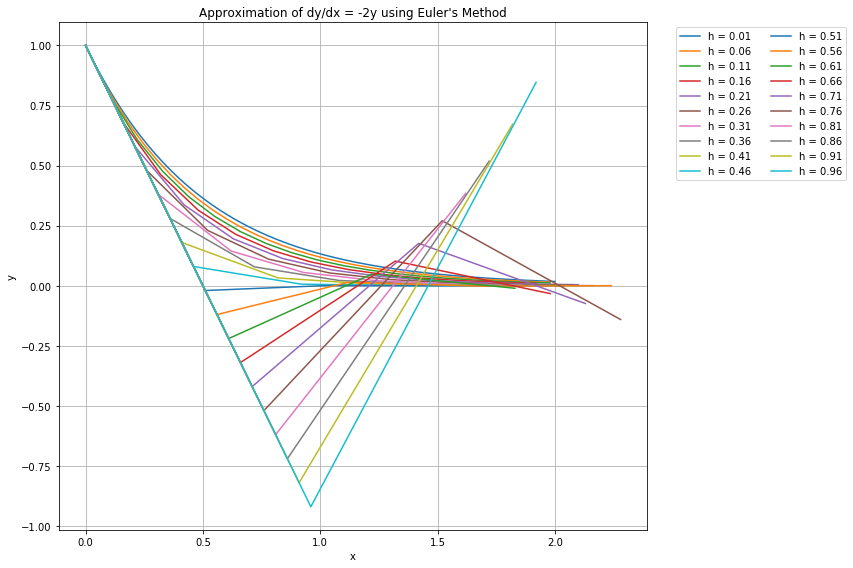

Comparing all runs against the base run (h = 0.01)

Run with h = 0.01
  x = 0.00 | Error = 0.000000
  x = 0.01 | Error = 0.000000
  x = 0.02 | Error = 0.000000
  ... (intermediate points omitted for brevity) ...
  x = 1.98 | Error = 0.000000
  x = 1.99 | Error = 0.000000
  x = 2.00 | Error = 0.000000
TOTAL Accumulated Error: 0.000000

Run with h = 0.06
  x = 0.00 | Error = 0.000000
  x = 0.06 | Error = 0.005842
  x = 0.12 | Error = 0.010317
  ... (intermediate points omitted for brevity) ...
  x = 1.86 | Error = 0.004328
  x = 1.92 | Error = 0.003945
  x = 1.98 | Error = 0.003592
TOTAL Accumulated Error: 0.392330

Run with h = 0.11
  x = 0.00 | Error = 0.000000
  x = 0.11 | Error = 0.020731
  x = 0.22 | Error = 0.032771
  ... (intermediate points omitted for brevity) ...
  x = 1.76 | Error = 0.009790
  x = 1.87 | Error = 0.008228
  x = 1.98 | Error = 0.006892
TOTAL Accumulated Error: 0.439800

Run with h = 0.16
  x = 0.00 | Error = 0.000000
  x = 0.16 | Error = 0.043798
  x = 0.32 | Er

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
x_start, x_end = 0, 2
step_sizes = np.arange(0.01, 1.01, 0.05)  # Loops from 0.01 to 1.00 in steps of 0.05

def f(x, y):
    return -2 * y

# Dictionary to store results for later error comparison
runs = {}

# Prepare the plot
plt.figure(figsize=(12, 8))

# Loop over each step size
for h in step_sizes:
    # Ensure num_steps handles floating point math cleanly
    num_steps = int(np.round((x_end - x_start) / h))
    
    # Generate arrays based on current step size
    x_values = np.linspace(x_start, x_start + num_steps * h, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    
    # Initial condition
    y_values[0] = 1  
    
    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
        
    # Save for error calculation later
    runs[h] = (x_values, y_values)
    
    # Add to plot
    plt.plot(x_values, y_values, label=f"h = {h:.2f}")

# Plot styling
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
# Place legend outside the main plot area to avoid covering lines
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()

# --- ERROR CALCULATION ---
# Compare each run to the "first run" (h = 0.01)
base_h = step_sizes[0]
base_x, base_y = runs[base_h]

print(f"Comparing all runs against the base run (h = {base_h:.2f})")
for h in step_sizes:
    x_values, y_values = runs[h]
    
    total_error = 0
    print(f"\n=============================")
    print(f"Run with h = {h:.2f}")
    print(f"=============================")
    
    for i, x in enumerate(x_values):
        # Find the closest corresponding x-value in the base run's grid
        base_idx = np.argmin(np.abs(base_x - x))
        
        # Pointwise Error
        err = abs(y_values[i] - base_y[base_idx])
        total_error += err
        
        # Print error for each point (can be hundreds, limiting print to first/last few for clean terminal output)
        if i < 3 or i > len(x_values) - 4:
            print(f"  x = {x:.2f} | Error = {err:.6f}")
        elif i == 3:
            print("  ... (intermediate points omitted for brevity) ...")
            
    print(f"TOTAL Accumulated Error: {total_error:.6f}")